###  1. Data Preparation:
Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).


In [191]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.feature_selection import chi2, f_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OrdinalEncoder,LabelEncoder
from sklearn.metrics import accuracy_score

In [192]:
df=pd.read_csv('heart_disease.csv')

In [193]:
df.shape

(999, 13)

In [194]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63.0,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,FALSE,2.3,downsloping,fixed defect,0.0
1,41.0,Male,atypical angina,135.0,203.0,False,normal,132.0,FALSE,0.0,flat,fixed defect,0.0
2,57.0,Male,asymptomatic,140.0,192.0,False,normal,148.0,FALSE,0.4,flat,fixed defect,0.0
3,52.0,Male,typical angina,118.0,186.0,False,lv hypertrophy,190.0,FALSE,0.0,flat,fixed defect,0.0
4,57.0,Male,asymptomatic,110.0,201.0,False,normal,126.0,TRUE,1.5,flat,fixed defect,0.0


In [195]:
## info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    float64
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    float64
 4   chol      908 non-null    float64
 5   fbs       908 non-null    object 
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    float64
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    float64
dtypes: float64(6), object(7)
memory usage: 101.6+ KB


### 2. Exploratory Data Analysis (EDA):
Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, and inconsistencies in the data.
Visualize the distribution of features, including histograms, box plots, and correlation matrices.


In [196]:
## duplicates
df.duplicated().sum()

np.int64(91)

In [197]:
df = df.drop_duplicates()

In [198]:
df.duplicated().sum()

np.int64(0)

In [199]:
## missing values
df.isnull().sum()

age          1
sex          1
cp           1
trestbps     1
chol         1
fbs          1
restecg      1
thalch       1
exang        1
oldpeak     63
slope        1
thal         1
num          1
dtype: int64

In [200]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 908 entries, 0 to 908
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       907 non-null    float64
 1   sex       907 non-null    object 
 2   cp        907 non-null    object 
 3   trestbps  907 non-null    float64
 4   chol      907 non-null    float64
 5   fbs       907 non-null    object 
 6   restecg   907 non-null    object 
 7   thalch    907 non-null    float64
 8   exang     907 non-null    object 
 9   oldpeak   845 non-null    float64
 10  slope     907 non-null    object 
 11  thal      907 non-null    object 
 12  num       907 non-null    float64
dtypes: float64(6), object(7)
memory usage: 99.3+ KB


In [201]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [202]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [203]:
## detection outlier
df.boxplot()

<Axes: >

In [204]:
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+ 1.5*IQR
    df[column]= df[column].apply(lambda x:lower_extreme if x< lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

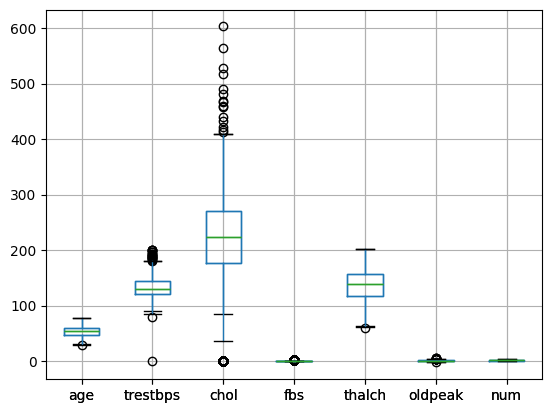

In [205]:
df.boxplot()
plt.show()

In [206]:
## describe
df.describe(include='all')

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
count,908.000000,908,908,908.000000,908.000000,908,908,908.000000,908,908.000000,908,908,908.000000
unique,NaN,2,4,NaN,NaN,2,3,NaN,3,NaN,3,3,NaN
top,NaN,Male,asymptomatic,NaN,NaN,False,normal,NaN,FALSE,NaN,flat,reversable defect,NaN
freq,NaN,718,496,NaN,NaN,723,543,NaN,536,NaN,454,353,NaN
mean,53.787858,NaN,NaN,133.261013,207.363023,NaN,NaN,135.980176,NaN,0.855396,NaN,NaN,1.007709
std,9.155855,NaN,NaN,19.292764,96.874776,NaN,NaN,26.795268,NaN,1.024412,NaN,NaN,1.143963
min,29.375000,NaN,NaN,84.000000,36.875000,NaN,NaN,61.000000,NaN,-2.250000,NaN,NaN,0.000000
25%,47.750000,NaN,NaN,120.000000,176.750000,NaN,NaN,118.000000,NaN,0.000000,NaN,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,224.000000,NaN,NaN,138.000000,NaN,0.500000,NaN,NaN,1.000000
75%,60.000000,NaN,NaN,144.000000,270.000000,NaN,NaN,156.000000,NaN,1.500000,NaN,NaN,2.000000


### 3. Feature Engineering:
If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.


In [207]:
features=df.drop(columns=['num'])
target=df[['num']]

In [208]:
target1=target.copy()
target1.head()

,num
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [209]:
target1['num'] = target1['num'].apply(lambda x: 0 if x == 0 else 1)

In [210]:
## Labeling
lab_enc=LabelEncoder()
target1['num']=lab_enc.fit_transform(target1['num'])
target1.head()

,num
0,0
1,0
2,0
3,0
4,0


In [211]:
# remove rare classes (count < 2)
counts = target1['num'].value_counts()
valid_classes = counts[counts > 1].index

df = df[df['num'].isin(valid_classes)]

### 4. Decision Tree Classification:
Split the dataset into training and testing sets (e.g., using an 80-20 split).
Implement a Decision Tree Classification model using a library like scikit-learn.
Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).


In [212]:
x_train, x_test, y_train, y_test = train_test_split(
    features, target1,
    train_size=0.8,
    random_state=100,
    stratify=target1['num']
)

In [213]:
### train_test_split
x_train,x_test,y_train,y_test=train_test_split(features,target1,train_size=0.8,random_state=100,stratify=target1.num)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(726, 12)
(182, 12)
(726, 1)
(182, 1)


In [214]:
x_train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal
249,48.0,Female,asymptomatic,120.0,254.0,False,st-t abnormality,110.0,FALSE,0.0,downsloping,reversable defect
255,50.0,Male,atypical angina,170.0,209.0,False,st-t abnormality,116.0,FALSE,0.0,flat,normal
115,35.0,Male,atypical angina,122.0,192.0,False,normal,174.0,FALSE,0.0,upsloping,normal
382,58.0,Male,asymptomatic,131.0,385.0,True,lv hypertrophy,126.0,TURE,0.5,flat,normal
275,39.0,Male,asymptomatic,110.0,273.0,False,normal,132.0,FALSE,0.0,downsloping,normal


In [215]:
df.thal.unique()

array(['fixed defect', 'normal', 'reversable defect'], dtype=object)

In [216]:
['FALSE', 'TRUE']   # not 'TURE'

['FALSE', 'TRUE']

In [217]:
ord_enc=OrdinalEncoder()
x_train[['cp','slope']]=ord_enc.fit_transform(x_train[['cp','slope']])
x_test[['cp','slope']]=ord_enc.transform(x_test[['cp','slope']])

In [218]:
x_train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal
249,48.0,Female,0.0,120.0,254.0,False,st-t abnormality,110.0,FALSE,0.0,0.0,reversable defect
255,50.0,Male,1.0,170.0,209.0,False,st-t abnormality,116.0,FALSE,0.0,1.0,normal
115,35.0,Male,1.0,122.0,192.0,False,normal,174.0,FALSE,0.0,2.0,normal
382,58.0,Male,0.0,131.0,385.0,True,lv hypertrophy,126.0,TURE,0.5,1.0,normal
275,39.0,Male,0.0,110.0,273.0,False,normal,132.0,FALSE,0.0,0.0,normal


In [219]:
features.sex.unique(),features.fbs.unique(),features.restecg.unique(),features.exang.unique(),features.thal.unique()


(array(['Male', 'Female'], dtype=object),
 array([ True, False]),
 array(['lv hypertrophy', 'normal', 'st-t abnormality'], dtype=object),
 array(['FALSE', 'TRUE', 'TURE'], dtype=object),
 array(['fixed defect', 'normal', 'reversable defect'], dtype=object))

In [220]:
# Fix typo in exang
features['exang'] = features['exang'].replace('TURE', 'TRUE')

# Standardize case (optional but good)
features['exang'] = features['exang'].str.upper()
# Convert fbs to string (optional for encoding consistency)
features['fbs'] = features['fbs'].astype(str)

In [221]:
feature_types = {
    "sex": "nominal",
    "fbs": "nominal (binary)",
    "restecg": "nominal",
    "exang": "nominal (binary)",
    "thal": "nominal"
}

In [222]:
## dummies for nominal
x_train=pd.get_dummies(x_train,dtype='int')

In [223]:
x_test=pd.get_dummies(x_test,dtype='int')

In [224]:
x_train.head()

,age,cp,trestbps,chol,fbs,thalch,oldpeak,slope,sex_Female,sex_Male,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,exang_FALSE,exang_TRUE,exang_TURE,thal_fixed defect,thal_normal,thal_reversable defect
249,48.0,0.0,120.0,254.0,False,110.0,0.0,0.0,1,0,0,0,1,1,0,0,0,0,1
255,50.0,1.0,170.0,209.0,False,116.0,0.0,1.0,0,1,0,0,1,1,0,0,0,1,0
115,35.0,1.0,122.0,192.0,False,174.0,0.0,2.0,0,1,0,1,0,1,0,0,0,1,0
382,58.0,0.0,131.0,385.0,True,126.0,0.5,1.0,0,1,1,0,0,0,0,1,0,1,0
275,39.0,0.0,110.0,273.0,False,132.0,0.0,0.0,0,1,0,1,0,1,0,0,0,1,0


In [225]:
x_train['fbs'] = x_train['fbs'].map({True: 1, False: 0})
x_test['fbs']  = x_test['fbs'].map({True: 1, False: 0})

In [226]:
x_train['fbs'].isnull().sum()

np.int64(0)

In [227]:
### features selection
f_clas=f_classif(x_train,y_train)
f_clas

(array([5.81651563e+01, 1.22322928e+02, 1.00534699e+01, 3.87947541e+01,
        1.79267474e+01, 1.10708476e+02, 1.08782165e+02, 1.80292115e+01,
        8.42119715e+01, 8.42119715e+01, 8.22550424e-02, 7.97990203e+00,
        1.01297003e+01, 1.80281886e+02, 1.77391921e+02, 5.41293364e-01,
        4.37936192e-02, 4.46033717e+01, 4.65045652e+01]),
 array([7.59282395e-14, 2.21693939e-26, 1.58471303e-03, 7.97970947e-10,
        2.59143174e-05, 3.43973307e-24, 7.99837738e-24, 2.45884518e-05,
        4.56254475e-19, 4.56254475e-19, 7.74346448e-01, 4.86010701e-03,
        1.52136885e-03, 7.29626537e-37, 2.33947394e-36, 4.62135487e-01,
        8.34296922e-01, 4.80840816e-11, 1.92944448e-11]))

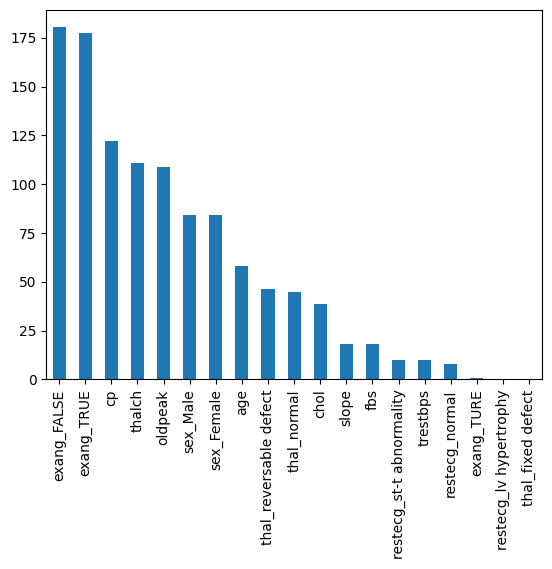

In [228]:
#### feature selection
f_clas= f_classif(x_train,y_train)
pd.Series(f_clas[0],index=x_train.columns).sort_values(ascending=False).plot(kind='bar')
plt.show()

In [229]:
std_sca=StandardScaler()
x_train[['age','trestbps','chol','thalch']]= std_sca.fit_transform(x_train[['age','trestbps','chol','thalch']])
x_test[['age','trestbps','chol','thalch']]= std_sca.transform(x_test[['age','trestbps','chol','thalch']])

### 5. Hyperparameter Tuning:
Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.


In [230]:
#### Model Building
dec_tree= DecisionTreeClassifier(criterion='gini',splitter='random',max_depth=5,random_state=100)
dec_tree.fit(x_train,y_train)
y_pred= dec_tree.predict(x_train)
train_acc=accuracy_score(y_train,y_pred)
y_pred1= dec_tree.predict(x_test)
test_acc=accuracy_score(y_test,y_pred1)
print('Train_Acc:',train_acc,',','Test_Acc:',test_acc)

Train_Acc: 0.8071625344352618 , Test_Acc: 0.7692307692307693


### 6. Model Evaluation and Analysis:
Analyse the performance of the Decision Tree model using the evaluation metrics obtained.
Visualize the decision tree structure to understand the rules learned by the model and identify important features


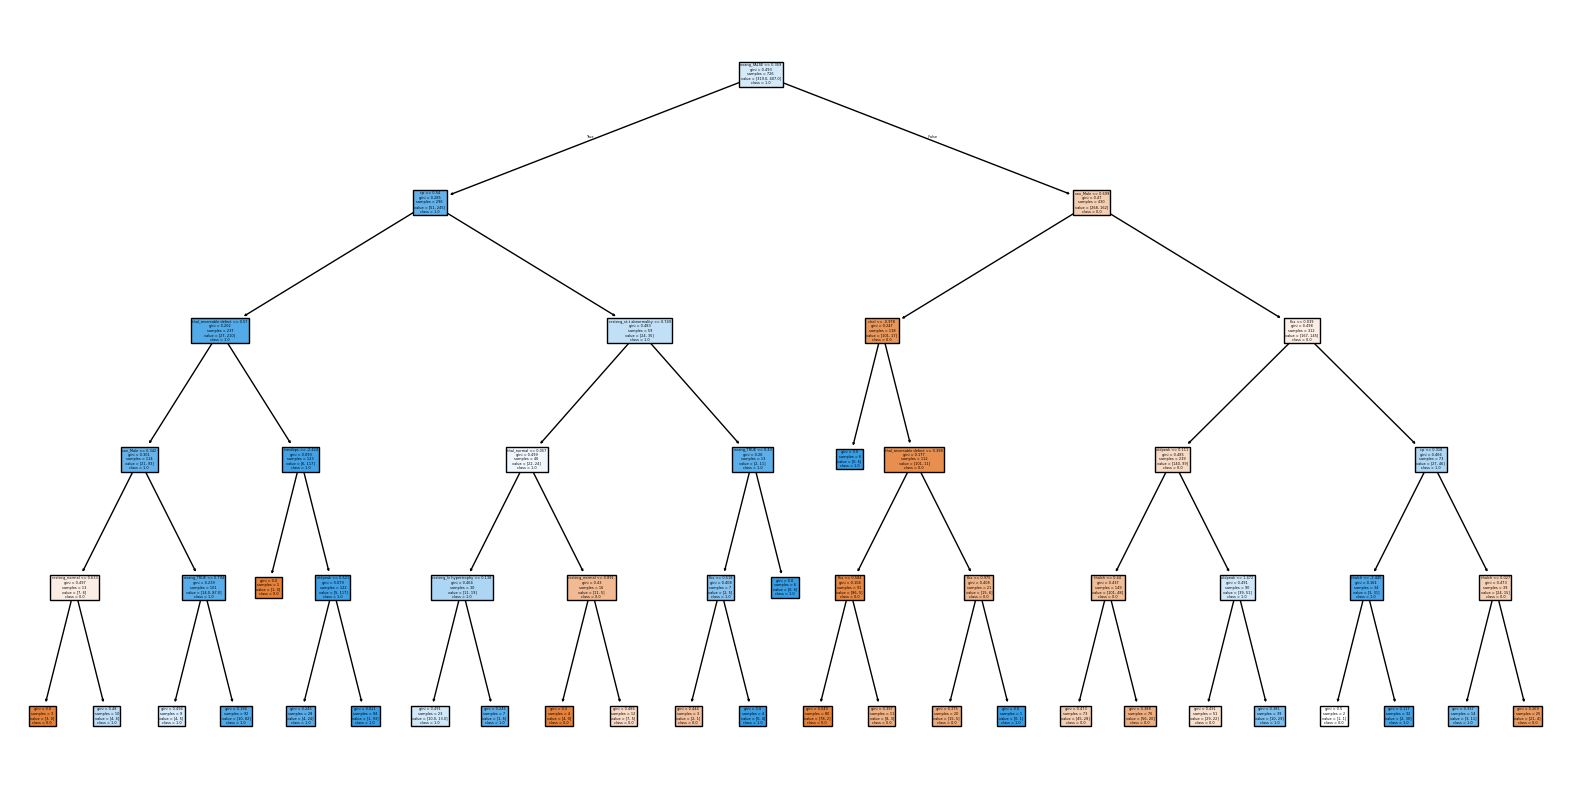

In [232]:
#### Plotting a tree
plt.figure(figsize=(20,10))
plot_tree(dec_tree,filled=True,feature_names=list(x_train),class_names=list(target['num'].astype(str).unique()))
plt.show();

In [234]:
#### GridSearch
from sklearn.model_selection import GridSearchCV

In [235]:
params= {'criterion':['gini','entropy'],'splitter':['best','random'],'max_depth':range(1,7)}

In [236]:
grid_search= GridSearchCV(estimator=dec_tree,param_grid=params,cv=5)

In [237]:
grid_search.fit(x_train,y_train)

GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(max_depth=5, random_state=100,
                                              splitter='random'),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(1, 7),
                         'splitter': ['best', 'random']})

In [238]:
grid_search.best_score_,grid_search.best_params_

(np.float64(0.7754369390647142),
 {'criterion': 'gini', 'max_depth': 5, 'splitter': 'random'})

In [239]:
y_pred = dec_tree.predict(x_test)

In [240]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.7692307692307693
Precision: 0.7799062639488171
Recall   : 0.7692307692307693
F1 Score : 0.7700125645679184


In [244]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred)
print("AUC Score:", auc_score)


AUC Score: 0.7752450980392157


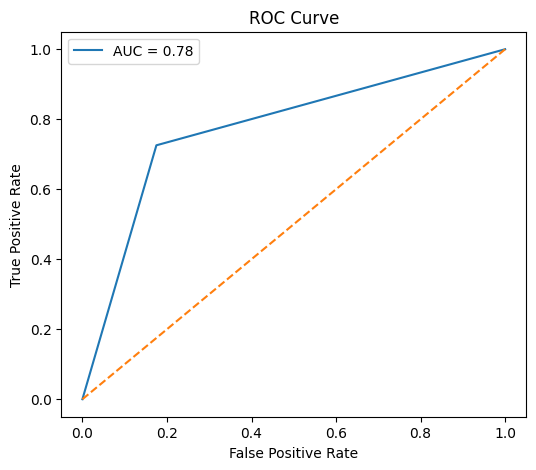

In [247]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle='--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Interview Questions: